# Model

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
import shap
shap.initjs()
import joblib

d:\Projects\Ai\Hr\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_model = pd.read_csv("Datasets/processed_hr_data_model.csv")

data_model.shape

(1470, 50)

In [3]:
data_model.columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'IsYoungEmployee',
       'LowIncome', 'LongDistance', 'PromotionDelay', 'HighRiskOvertime',
       'Attrition_Yes', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'Gender_Male', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'Job

In [4]:
X = data_model.drop('Attrition_Yes', axis=1)
y = data_model['Attrition_Yes']

In [5]:
print(X.shape)
print(y.shape)

(1470, 49)
(1470,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
lr = LogisticRegression(max_iter=5000,random_state=42)

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

In [9]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 0.8605442176870748
Precision: 0.6153846153846154
Recall   : 0.3404255319148936
F1 Score : 0.4383561643835616
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [10]:
confusion_matrix(y_test, y_pred)

array([[237,  10],
       [ 31,  16]])

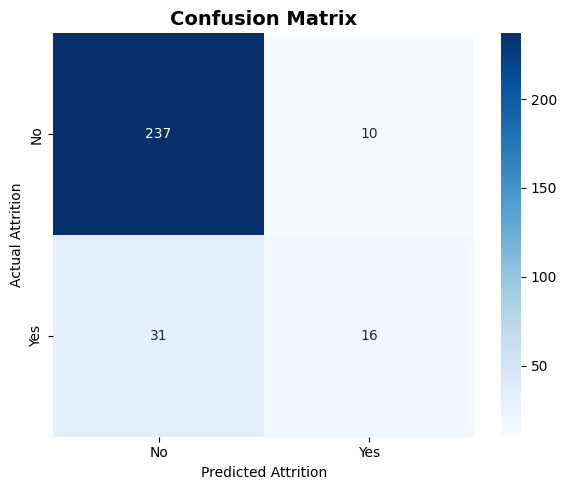

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Attrition')
plt.ylabel('Actual Attrition')

plt.tight_layout()
plt.show()

In [12]:
lr_balanced = LogisticRegression(max_iter=5000,random_state=42,class_weight='balanced')

lr_balanced.fit(X_train_scaled, y_train)

y_pred = lr_balanced.predict(X_test_scaled)

In [13]:
lr_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = lr_balanced.predict(X_test_scaled)

In [14]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 0.7721088435374149
Precision: 0.38095238095238093
Recall   : 0.6808510638297872
F1 Score : 0.48854961832061067
              precision    recall  f1-score   support

           0       0.93      0.79      0.85       247
           1       0.38      0.68      0.49        47

    accuracy                           0.77       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.77      0.80       294



In [15]:
confusion_matrix(y_test, y_pred)

array([[195,  52],
       [ 15,  32]])

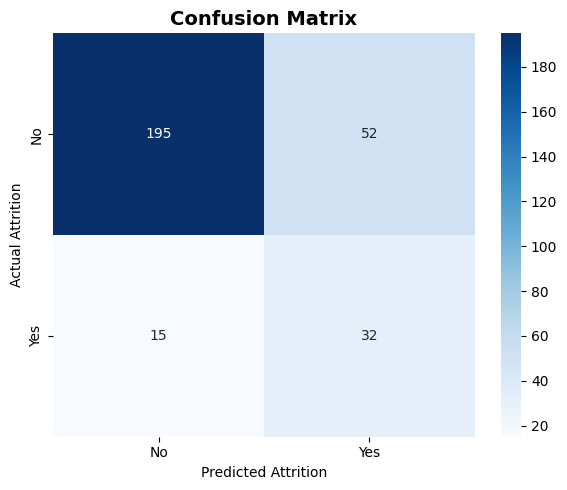

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Attrition')
plt.ylabel('Actual Attrition')

plt.tight_layout()
plt.show()

In [17]:
rf = RandomForestClassifier(n_estimators=300,random_state=42,class_weight='balanced')

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [18]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 0.7721088435374149
Precision: 0.38095238095238093
Recall   : 0.6808510638297872
F1 Score : 0.48854961832061067
              precision    recall  f1-score   support

           0       0.93      0.79      0.85       247
           1       0.38      0.68      0.49        47

    accuracy                           0.77       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.77      0.80       294



In [19]:
confusion_matrix(y_test, y_pred)

array([[195,  52],
       [ 15,  32]])

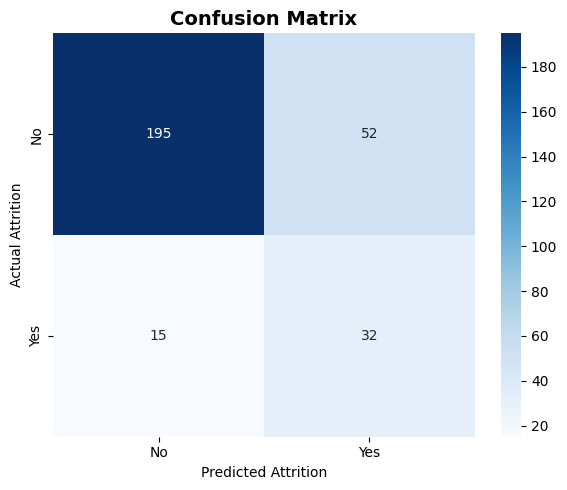

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Attrition')
plt.ylabel('Actual Attrition')

plt.tight_layout()
plt.show()

In [21]:
importance = pd.DataFrame({'Feature': X.columns,'Importance': rf.feature_importances_})

importance.sort_values(by='Importance',ascending=False).head(15)

,Feature,Importance
9,MonthlyIncome,0.070565
0,Age,0.057326
16,TotalWorkingYears,0.051793
1,DailyRate,0.051267
19,YearsAtCompany,0.046477
5,HourlyRate,0.045135
10,MonthlyRate,0.044822
2,DistanceFromHome,0.041447
22,YearsWithCurrManager,0.038545
48,OverTime_Yes,0.036892


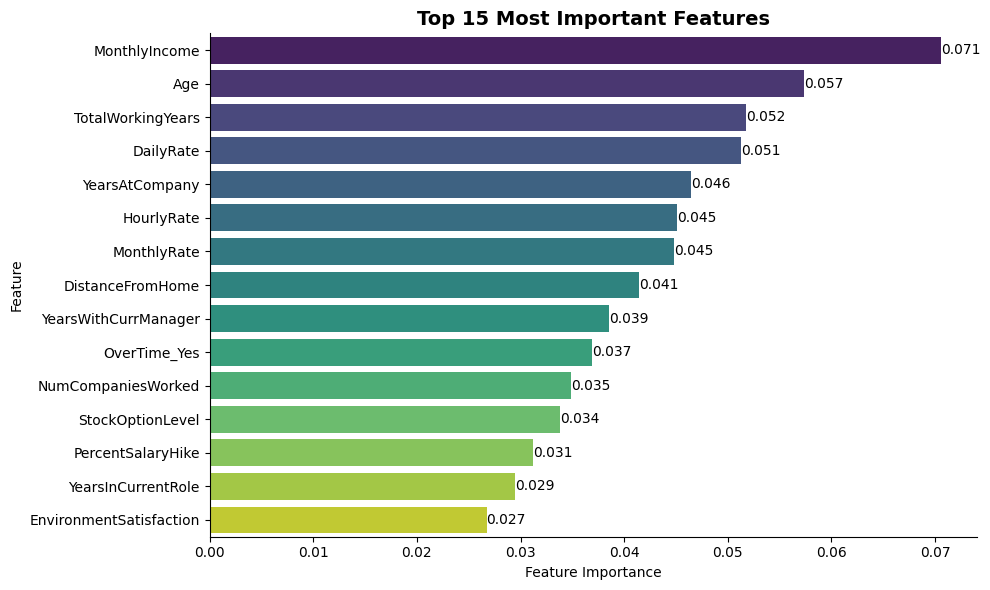

In [22]:
top15 = (
    importance
    .sort_values(by='Importance', ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot( data=top15, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

sns.despine()
plt.tight_layout()
plt.show()

In [23]:
xgb = XGBClassifier(n_estimators=300, learning_rate=0.075, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss')

xgb.fit(X_train, y_train)

y_proba = xgb.predict_proba(X_test)[:, 1]

threshold = 0.10
y_pred_xgb = (y_proba >= threshold).astype(int)

In [24]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))

Accuracy : 0.7959183673469388
Precision: 0.41333333333333333
Recall   : 0.6595744680851063
F1 Score : 0.5081967213114754
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       247
           1       0.41      0.66      0.51        47

    accuracy                           0.80       294
   macro avg       0.67      0.74      0.69       294
weighted avg       0.84      0.80      0.81       294



In [25]:
confusion_matrix(y_test, y_pred_xgb)

array([[203,  44],
       [ 16,  31]])

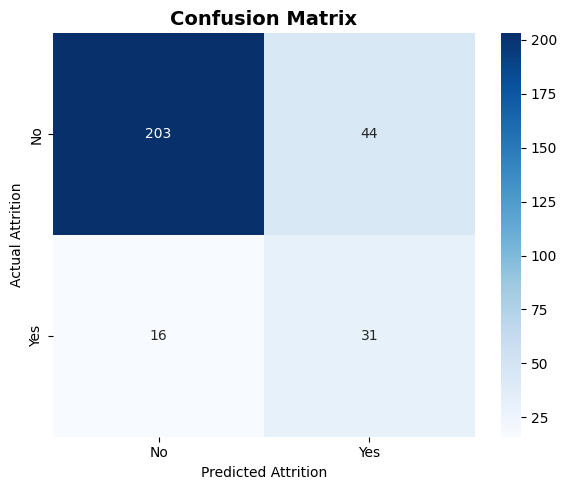

In [26]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Attrition')
plt.ylabel('Actual Attrition')

plt.tight_layout()
plt.show()

In [27]:
importance = pd.DataFrame({'Feature': X.columns,'Importance': xgb.feature_importances_})

importance = importance.sort_values(by='Importance', ascending=False).head(15)

importance

,Feature,Importance
27,HighRiskOvertime,0.059959
7,JobLevel,0.049035
48,OverTime_Yes,0.044551
44,JobRole_Sales Executive,0.034678
45,JobRole_Sales Representative,0.033182
15,StockOptionLevel,0.030834
25,LongDistance,0.028968
43,JobRole_Research Scientist,0.028647
19,YearsAtCompany,0.028257
16,TotalWorkingYears,0.026392


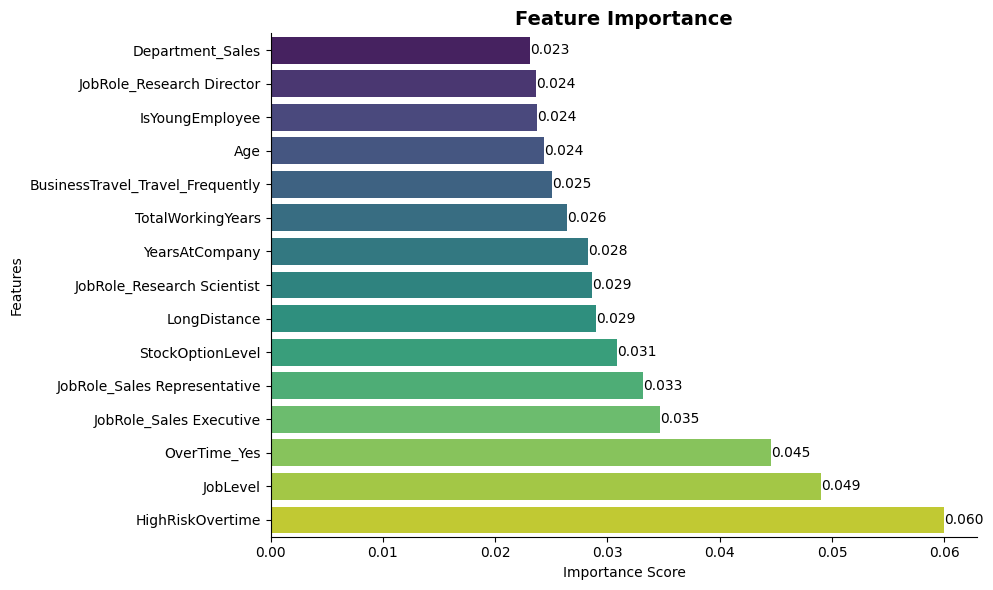

In [28]:
importance_sorted = importance.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))

ax = sns.barplot( data=importance_sorted, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.title('Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')

sns.despine()
plt.tight_layout()
plt.show()

In [29]:
final_model = xgb
final_threshold = 0.10

In [30]:
y_proba = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba >= final_threshold).astype(int)

In [31]:
print(classification_report(y_test, y_pred_final))
confusion_matrix(y_test, y_pred_final)

              precision    recall  f1-score   support

           0       0.93      0.82      0.87       247
           1       0.41      0.66      0.51        47

    accuracy                           0.80       294
   macro avg       0.67      0.74      0.69       294
weighted avg       0.84      0.80      0.81       294



array([[203,  44],
       [ 16,  31]])

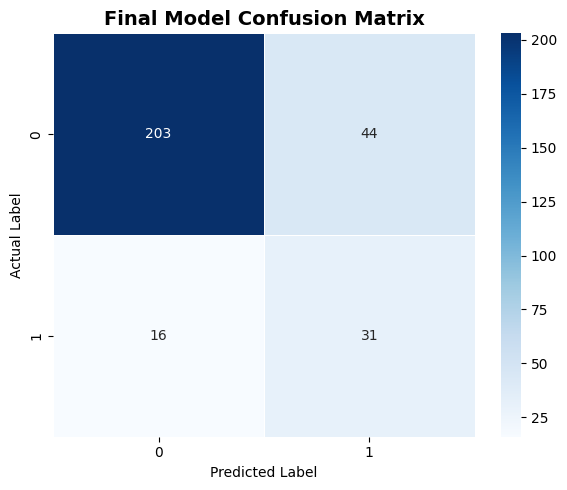

In [32]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white'
)

plt.title("Final Model Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [33]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

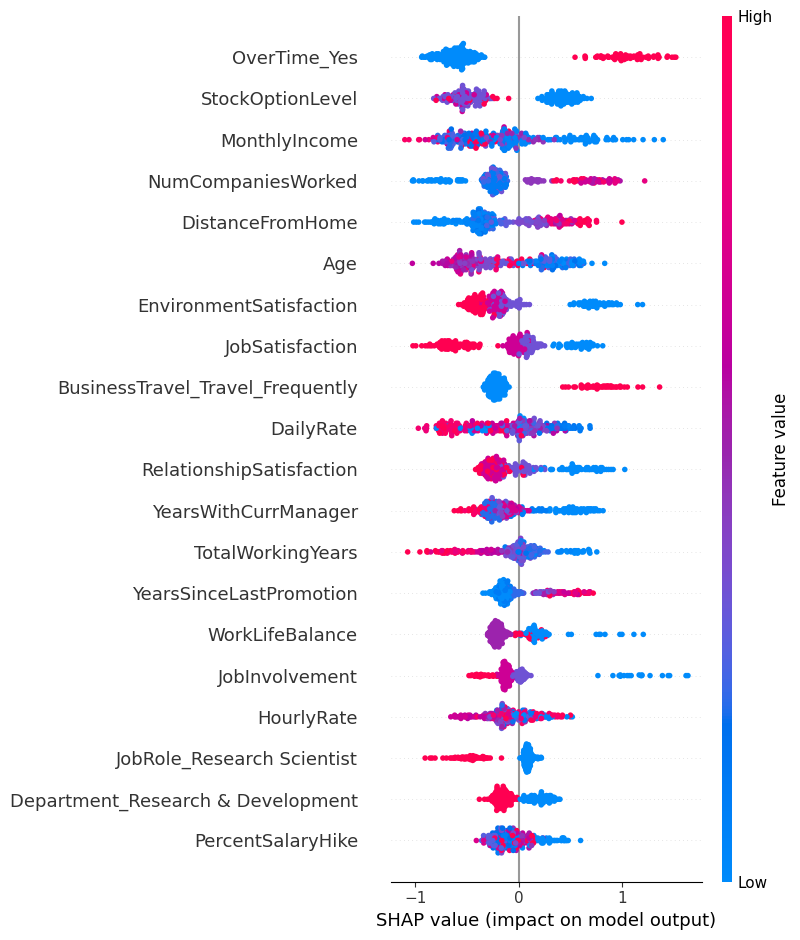

In [34]:
shap.summary_plot(shap_values, X_test)

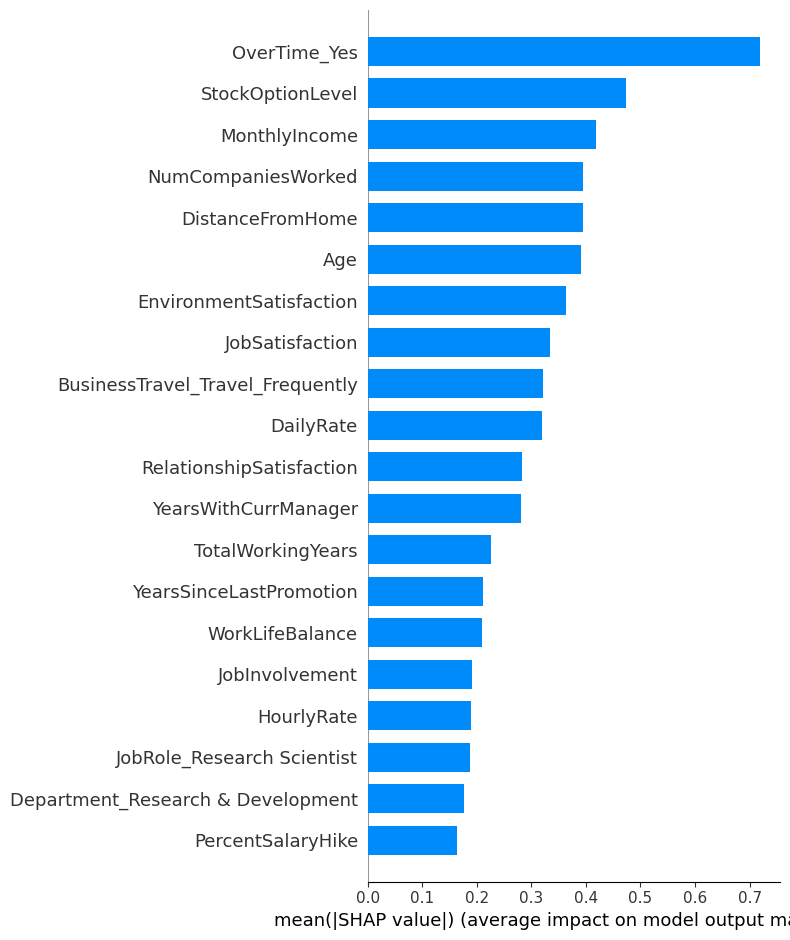

In [35]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [36]:
i = 0
shap.plots.force(explainer.expected_value,shap_values[i], X_test.iloc[i])

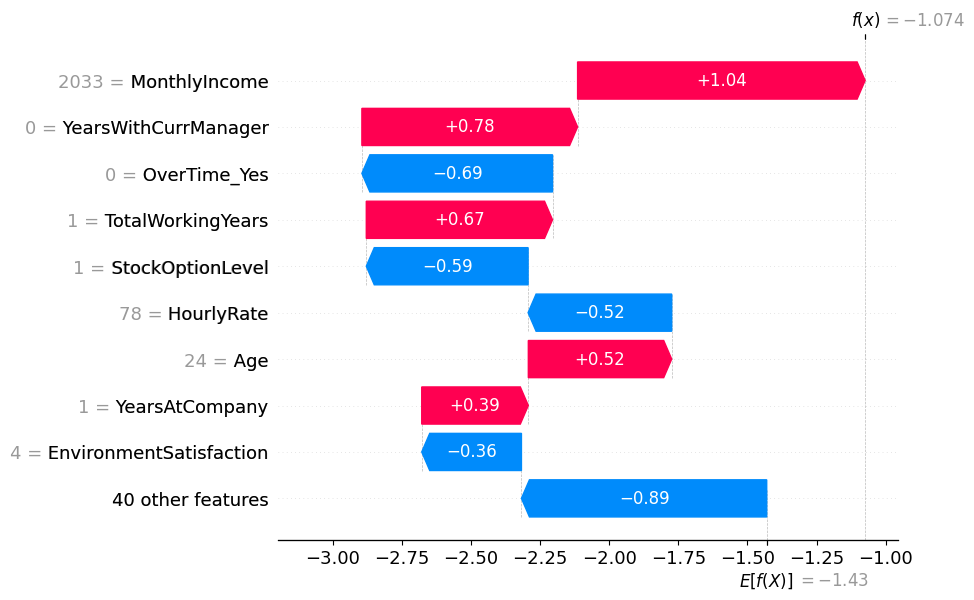

In [37]:
shap.waterfall_plot(shap.Explanation(values=shap_values[i], base_values=explainer.expected_value, data=X_test.iloc[i]))

In [38]:
joblib.dump(xgb, 'models/xgb_model.pkl')

['models/xgb_model.pkl']

In [39]:
joblib.dump(X.columns.tolist(), "models/model_columns.pkl")

['models/model_columns.pkl']

In [40]:
joblib.dump(0.10,"models/threshold.pkl")

['models/threshold.pkl']

In [41]:
income_median = 4919
joblib.dump(income_median, "models/income_median.pkl")

['models/income_median.pkl']

In [42]:
model = joblib.load("models/xgb_model.pkl")
columns = joblib.load("models/model_columns.pkl")
threshold = joblib.load("models/threshold.pkl")

print(len(columns))
print(threshold)

49
0.1


In [43]:
employee = {
    'Age': 25,
    'DailyRate': 800,
    'DistanceFromHome': 15,
    'Education': 3,
    'EnvironmentSatisfaction': 2,
    'HourlyRate': 70,
    'JobInvolvement': 2,
    'JobLevel': 1,
    'JobSatisfaction': 2,
    'MonthlyIncome': 2500,
    'MonthlyRate': 12000,
    'NumCompaniesWorked': 3,
    'PercentSalaryHike': 12,
    'PerformanceRating': 3,
    'RelationshipSatisfaction': 2,
    'StockOptionLevel': 0,
    'TotalWorkingYears': 2,
    'TrainingTimesLastYear': 2,
    'WorkLifeBalance': 2,
    'YearsAtCompany': 1,
    'YearsInCurrentRole': 1,
    'YearsSinceLastPromotion': 0,
    'YearsWithCurrManager': 1,

    'BusinessTravel': 'Travel_Frequently',
    'Department': 'Sales',
    'EducationField': 'Marketing',
    'Gender': 'Male',
    'JobRole': 'Sales Representative',
    'MaritalStatus': 'Single',
    'OverTime': 'Yes'
}

In [44]:
df = pd.DataFrame([employee])

In [45]:
income_median = 4919

df['IsYoungEmployee'] = np.where(df['Age'] < 30,1,0)

df['LowIncome'] = np.where(df['MonthlyIncome'] < income_median,1,0)

df['LongDistance'] = np.where(df['DistanceFromHome'] > 10,1,0)

df['PromotionDelay'] = np.where(df['YearsSinceLastPromotion'] >= 5,1,0)

df['HighRiskOvertime'] = np.where((df['OverTime'] == 'Yes') & (df['JobRole'].isin(['Sales Representative','Laboratory Technician','Human Resources'])),1,0)

In [46]:
df = pd.get_dummies(df)

In [47]:
model_columns = joblib.load("models/model_columns.pkl")

In [48]:
df = df.reindex( columns=model_columns, fill_value=0)

In [49]:
print(df.shape)

(1, 49)


In [50]:
model = joblib.load("models/xgb_model.pkl")

prob = model.predict_proba(df)[0][1]

print(prob)

0.99683845


In [51]:
threshold = 0.10

prediction = int(prob >= threshold)

In [52]:
if prediction == 1:
    print("High Attrition Risk")
else:
    print("Low Attrition Risk")

High Attrition Risk


In [53]:
employee_2 = {
    'Age': 45,
    'DailyRate': 1000,
    'DistanceFromHome': 3,
    'Education': 4,
    'EnvironmentSatisfaction': 4,
    'HourlyRate': 80,
    'JobInvolvement': 4,
    'JobLevel': 4,
    'JobSatisfaction': 4,
    'MonthlyIncome': 15000,
    'MonthlyRate': 20000,
    'NumCompaniesWorked': 1,
    'PercentSalaryHike': 15,
    'PerformanceRating': 4,
    'RelationshipSatisfaction': 4,
    'StockOptionLevel': 3,
    'TotalWorkingYears': 20,
    'TrainingTimesLastYear': 3,
    'WorkLifeBalance': 4,
    'YearsAtCompany': 15,
    'YearsInCurrentRole': 8,
    'YearsSinceLastPromotion': 1,
    'YearsWithCurrManager': 10,

    'BusinessTravel': 'Travel_Rarely',
    'Department': 'Research & Development',
    'EducationField': 'Medical',
    'Gender': 'Male',
    'JobRole': 'Manager',
    'MaritalStatus': 'Married',
    'OverTime': 'No'
}

In [54]:
df_2 = pd.DataFrame([employee_2])

In [55]:
income_median = 4919

df_2['IsYoungEmployee'] = np.where(df_2['Age'] < 30,1,0)

df_2['LowIncome'] = np.where(df_2['MonthlyIncome'] < income_median,1,0)

df_2['LongDistance'] = np.where(df_2['DistanceFromHome'] > 10,1,0)

df_2['PromotionDelay'] = np.where(df_2['YearsSinceLastPromotion'] >= 5,1,0)

df_2['HighRiskOvertime'] = np.where((df_2['OverTime'] == 'Yes') & (df_2['JobRole'].isin(['Sales Representative','Laboratory Technician','Human Resources'])),1,0)

In [56]:
df_2 = pd.get_dummies(df_2)

In [57]:
model_columns = joblib.load("models/model_columns.pkl")

In [58]:
df_2 = df_2.reindex( columns=model_columns, fill_value=0)

In [59]:
print(df_2.shape)

(1, 49)


In [60]:
model = joblib.load("models/xgb_model.pkl")

prob = model.predict_proba(df_2)[0][1]

print(prob)

0.00029925606


In [61]:
threshold = 0.10

prediction = int(prob >= threshold)

In [62]:
if prediction == 1:
    print("High Attrition Risk")
else:
    print("Low Attrition Risk")

Low Attrition Risk


In [63]:
artifacts = {"model": model,"columns": model_columns,"threshold": 0.10,"income_median": income_median}

In [64]:
sample = X_test.sample(10, random_state=42)

probs = model.predict_proba(sample)[:,1]

for i, p in enumerate(probs):
    print(f"Employee {i+1}: {p:.2%}")

Employee 1: 2.71%
Employee 2: 52.84%
Employee 3: 12.70%
Employee 4: 1.44%
Employee 5: 1.58%
Employee 6: 1.35%
Employee 7: 17.87%
Employee 8: 2.31%
Employee 9: 0.14%
Employee 10: 0.52%
